Workflow;
1. Setup and installation
2. Introduction to boosting.
3. Dataset is Irish flower dataset. 
4. Data exploration 
5. model1: XGBoost
5. model2: LightBoost
6. model 3: CatBoost
7. Model comparision 
8. Visualization 
9. 

In [1]:
#Setting up core libraries
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#modeling and evaluation imports
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, 
    f1_score,
    classification_report, 
    confusion_matrix, 
    roc_curve, 
    auc, 
    roc_auc_score, 

)
#importing Boosting models : 
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

RANDOM_STATE = 42

In [2]:
#Looding the dataset. 
irish = pd.read_csv('D:\Skill Morph\class13\data\Iris.csv')
irish.head()

<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
C:\Users\AK2.0\AppData\Local\Temp\ipykernel_22164\2458443099.py:2: SyntaxWarning: invalid escape sequence '\S'
  irish = pd.read_csv('D:\Skill Morph\class13\data\Iris.csv')


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
#features dropping identifiers and target column 
X = irish.drop(['Id', "Species"], axis = 1)
le = LabelEncoder()
y = le.fit_transform(irish['Species'])
class_names = le.classes_
n_classes = len(class_names)
print("Dataset Loaded successfully")
print(f"Feature matrix shape: {X.shape}")
print(f"Number of classes : {n_classes} ")
print(f" Target classes : {list(class_names)}")

Dataset Loaded successfully
Feature matrix shape: (150, 4)
Number of classes : 3 
 Target classes : ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


In [4]:
print(X.head())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2


In [5]:
#Train test split 80:20;
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size= 0.2,
                                                    random_state= RANDOM_STATE, 
                                                    stratify= y,)
print("Data split completed")
print(f"Training Samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Data split completed
Training Samples: 120
Test samples: 30


In [6]:
#Model 1 XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators = 50,
    learning_rate = 0.1,
    max_depth = 5,
    random_state = RANDOM_STATE,
    eval_metric = "mlogloss",
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
print(f"accuracy ={(xgb_acc * 100):.4f}")

accuracy =96.6667


In [7]:
#Integrating model 2: LightBoost:
lgb_model =lgb.LGBMClassifier(
    n_estimators= 50,
    learning_rate= 0.1,
    max_depth= 5,
    random_state= 42, verbose = -1,

)

lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)
lgb_prob = lgb_model.predict_proba(X_test)
lgb_acc = accuracy_score(y_test, lgb_pred)

print(f"LightBoost accuracy score is : {(lgb_acc *100 ):.4f}")

LightBoost accuracy score is : 90.0000


In [8]:
#integrating 3rd model: CatBoost
cat_model = CatBoostClassifier(
    n_estimators= 50,
    learning_rate= 0.1, 
    max_depth= 5,
    random_state= RANDOM_STATE,
    verbose = 0,
)
cat_model.fit(X_train, y_train)
cat_pred = cat_model.predict(X_test)
cat_prob = cat_model.predict_proba(X_test)
cat_acc = accuracy_score(y_test, cat_pred)
print(f"The accuracy score of Catboost model is : {(cat_acc * 100):.4f}")

The accuracy score of Catboost model is : 96.6667


In [9]:
#comparing the models : 
models = {
    "XGBoost": (xgb_pred, xgb_prob),
    "LightBoost": (lgb_pred, lgb_prob),
    "CatBoost": (cat_pred, cat_prob)
}
# Comparing all models precision , recall , f1_score...
from sklearn.metrics import precision_score, recall_score, f1_score
rows = []
for name, (pred, prob) in models.items ():
    rows.append({
        "Model": name, 
        "Accureacy ": accuracy_score(y_test, pred), 
        "Precission": precision_score(y_test, pred, average="macro"),
        "Recall ": recall_score(y_test, pred, average= "macro"),
        "F1 Score": f1_score(y_test, pred, average= "macro")
    })

results = pd.DataFrame(rows).sort_values("F1 Score", ascending= False).reset_index(drop= True)
#show tables rounded to 4 decimal points: 
print("Model Comparision on test set: ")
display(results.round(4))

best_model = results.iloc[0]['Model']
print(f"\n Best model by F1 score: {best_model}")

Model Comparision on test set: 


,Model,Accureacy,Precission,Recall,F1 Score
0,XGBoost,0.9667,0.9697,0.9667,0.9666
1,CatBoost,0.9667,0.9697,0.9667,0.9666
2,LightBoost,0.9000,0.9024,0.9000,0.8997



 Best model by F1 score: XGBoost


In [10]:
# Per class precission, recall, f1_score  for the best model...
best_pred = models[best_model][0]
print(f"Classification report  -- {best_model} \n")
print(classification_report(y_test, best_pred, target_names = class_names))

Classification report  -- XGBoost 

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



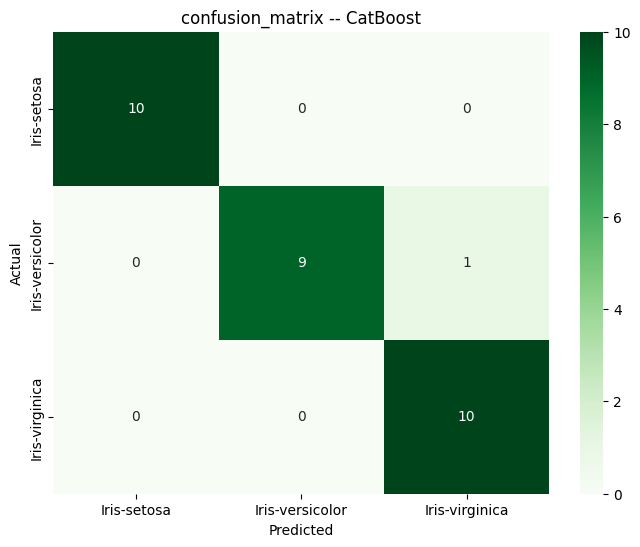

In [11]:
#Confusion matrix for catboost:
cm = confusion_matrix(y_test, cat_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot= True, fmt='d', cmap ='Greens',
            xticklabels=class_names, yticklabels= class_names)
plt.title("confusion_matrix -- CatBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

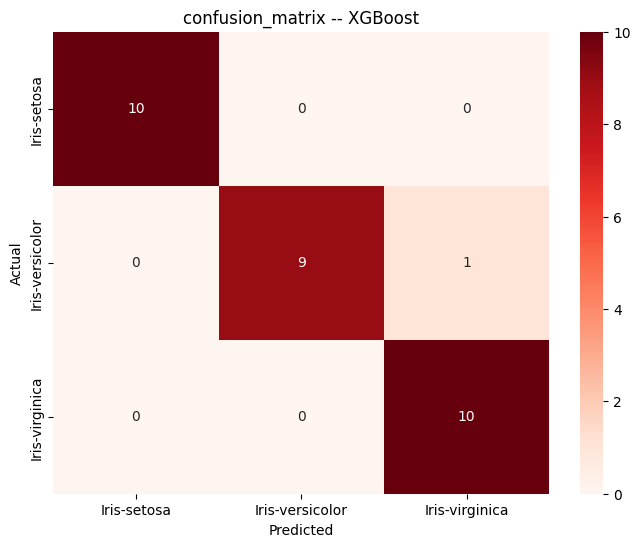

In [12]:
#confusion matrix for XGBosst: 
#Confusion matrix for catboost:
cm = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot= True, fmt='d', cmap ='Reds',
            xticklabels=class_names, yticklabels= class_names)
plt.title("confusion_matrix -- XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

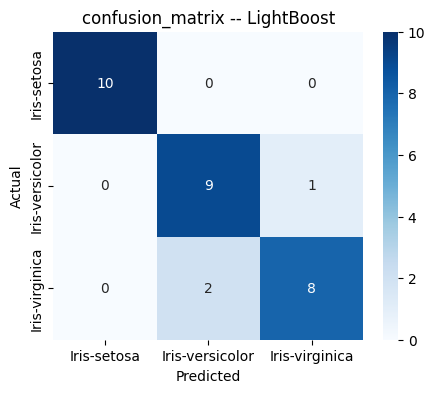

In [13]:
#confusion matrix for LightBoost: 
#Confusion matrix for catboost:
cm = confusion_matrix(y_test, lgb_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot= True, fmt='d', cmap ='Blues',
            xticklabels=class_names, yticklabels= class_names)
plt.title("confusion_matrix -- LightBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

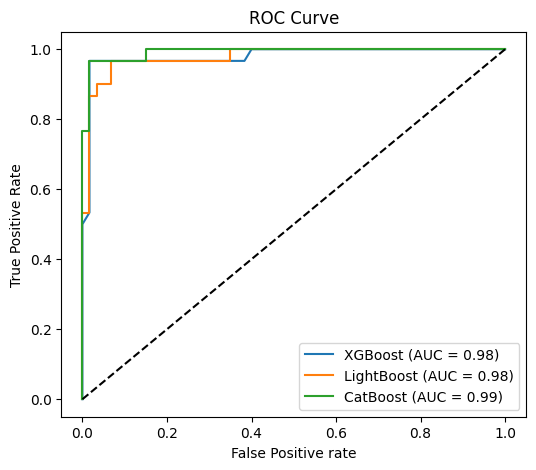

In [14]:
#Roc curve: 
y_bin = label_binarize(y_test, classes = range(n_classes))

plt.figure(figsize=(6,5))
for name, (pred, proba) in models.items(): 
    fpr, tpr, _ = roc_curve(y_bin.ravel(), proba.ravel())
    score = roc_auc_score(y_bin, proba, average="macro")

    plt.plot(fpr, tpr, label = f"{name} (AUC = {score:.2f})")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()